# Noise-layer baseline: three I-JEPA layers plus an attended noise source

## Main idea

This notebook follows `baseline_model_dev.ipynb`, but concatenates an explicit Gaussian-noise vector to the three frozen I-JEPA layer vectors before attention. The resulting tensor has four attended sources: three image-dependent representations and one image-independent noise control. The final heatmap keeps the noise source as its own row, so its attention mass can be inspected directly.

The central hypothesis is therefore:

> Can the temporal decoder learn to reject a stimulus-independent feature source, and does its attention to that noise source change over neural time?

The complete pipeline is:

```text
Static image
    |
    +-- Frozen I-JEPA ViT-H/14, or cached I-JEPA activations
    |
    v
Three real layer representations [B, 3, 1280]
    +
Independent Gaussian sphere noise [B, 1, 1280]
    | concatenate along the source/layer axis
    v
Attended source tensor [B, 4, 1280]
    +-- layer mode: project four whole source vectors
    +-- feature mode: expose 4 x 1280 source coordinates
    |
Learned temporal embeddings [30, 256]
    |
    v
Attention at each time point
    +-- layer weights   [B, 30, 4]
    +-- feature weights [B, 30, 4, 1280]
    |
    v
Time-indexed latent representation [B, 30, 128]
    |
    v
Temporal MLP and neural prediction MLP
    |
    v
Predicted AIT activity [B, 30 time bins, 25 neurons]
```

## Current configuration

The configuration uses monkey `three0`, session `250313`, area `AIT`, and stimulus set `talia_20each_tizi`. Neural activity is taken from `natraster` between 0 and 300 ms and resampled from 1000 Hz to 100 Hz, producing 30 ten-millisecond bins. The resulting data contain 776 stimuli and 25 AIT channels.

The visual backbone is I-JEPA ViT-H/14 at an input resolution of 224 x 224 pixels. Mean-pooled representations are taken from encoder layers 4, 17, and 27, matching the established I-JEPA configuration used elsewhere in this project. Each selected layer contributes a 1280-dimensional vector. The current run uses cached activations with shape `[776, 3, 1280]`; raw-image input is also supported.

Training uses a batch size of 256, a 20% validation fraction, 500 epochs, AdamW with learning rate `1e-3` and weight decay `1e-4`, and dropout `0.3`. The temporal embedding dimension is 256, the value dimension is 128, and the decoder hidden dimension is 32. `attention_granularity` selects `"layer"` or `"feature"`; the current configuration uses feature-level attention. A fresh noise vector is sampled per image and forward pass, with its norm matched to the mean norm of that image's three real layer vectors. Noise remains active during evaluation, and the final heatmap averages repeated draws.

## 1. Neural-data loading and alignment

The neural loaders return activity with shape `[neurons, time, samples]`. Two source formats are supported:

- `natraster`, used for the model targets, contains unique-image averaged responses. It loads the requested temporal window, converts the data to `float32`, selects the requested brain-area channels, resamples the signal, and aligns its stimulus dimension to the `ImageFolder` ordering. The configured result has shape `[25, 30, 776]`.
- `raster` contains repeated single trials. It loads neural data in chunks, reads the filename associated with each trial, and maps every occurrence to the corresponding source image. Repeated presentations remain separate neural samples.

When `use_reliability_weighted_loss=True`, a repeated `raster` is loaded to estimate target reliability even if `natraster` supplies the prediction targets. Only training-image identities contribute to the weights. When the flag is false, no repeated raster is loaded and the model uses ordinary MSE, allowing natraster-only datasets such as Paul.

Stimulus alignment is an essential part of the pipeline. `neural_image_indices` maps every neural sample to the correct row of the image dataset or cached activation array. The notebook checks that the number of mappings agrees with the neural sample dimension and that every mapped index is valid.

## 2. Visual inputs and frozen I-JEPA features

Images are indexed through `torchvision.datasets.ImageFolder`. `ProcessorTransform` applies the preprocessing recipe saved with the Hugging Face checkpoint, and the notebook verifies that the processor returns the configured 224 x 224 spatial resolution. Class labels created by `ImageFolder` are not used.

There are two input modes:

- With `training_input_mode="activations"`, the loader returns precomputed features with shape `[layers, embedding] = [3, 1280]`. This is the efficient default because the backbone is frozen.
- With `training_input_mode="images"`, the loader returns a processed image with shape `[3, 224, 224]`. I-JEPA is then run online under `torch.no_grad()`, and forward hooks collect the selected layer outputs.

In both modes, I-JEPA is used only as a fixed feature extractor. All its parameters have `requires_grad=False`, and the model overrides `train()` so that the backbone remains in evaluation mode while the decoder is trained.

## 3. Dataset and DataLoaders

`NeuralInputDataset` joins each visual input to its neural target. It transposes neural activity from `[neurons, time, samples]` to `[samples, time, neurons]`. A sample therefore contains either cached features `[3, 1280]` or an image `[3, 224, 224]`, together with a target `[30, 25]`.

The class performs early checks for invalid modes, missing cached activations, incorrect tensor dimensions, mismatches between neural trials and image mappings, and indices outside the source image dataset.

The train/validation split is made over unique image identities rather than directly over trials. This is important in `raster` mode: every repeated presentation of one image is kept in the same partition, preventing image leakage. The executed split contains 621 training images and 155 validation images. Training batches are shuffled; validation batches are not.

## 4. Model architecture

### Frozen encoder

The encoder is a 32-block I-JEPA ViT-H/14 with embedding dimension 1280. Three intermediate layer representations are retained. `NoiseLayerBaselineModel` appends one pseudo-layer by sampling an isotropic Gaussian vector, normalizing it to the unit sphere, and optionally matching its norm to the real features. The trainable network operates on the resulting four-source tensor rather than modifying the backbone.

### Layer-level and feature-level attention inputs

The model supports two attention granularities. With `attention_granularity="layer"`, each 1280-dimensional real or noise vector is projected into one key and one value of dimension 128:

```text
source features X: [B, 4, 1280]
keys K:            [B, 4, 128]
values V:          [B, 4, 128]
```

With `attention_granularity="feature"`, the attention axis instead contains all `4 * 1280 = 5120` individual source coordinates. Every source-coordinate pair has its own learned 256-dimensional key direction. Its activation modulates that key, making feature selection stimulus-dependent. Attention gates the normalized source tensor, which is flattened and projected from 5120 coordinates into the 128-dimensional value space. These are embedding/channel features from the mean-pooled layer output plus the matched noise vector, not spatial patch tokens.

### Noise as an attended source

The network learns one query for every neural time point. With 30 target bins and a temporal compression ratio of one, there are 30 queries of dimension 256. `NoiseLayerBaselineModel` leaves these queries unchanged and instead concatenates a newly sampled noise pseudo-layer to the three real layer vectors. Noise is sampled independently for each image and forward pass. It carries no stable stimulus information, so attention assigned to its row is an explicit negative-control measurement.

In layer mode, scaled dot-product attention is computed over the four sources $s$ (three I-JEPA layers plus noise):

$$A_{bts} = \operatorname{softmax}_s\left(\frac{Q_t K_{bs}^{T}}{\sqrt{d_k}}\right).$$

In feature mode, the same query scores every source-coordinate pair and the softmax is taken jointly over all 5120 coordinates:

$$A_{btse} = \operatorname{softmax}_{s,e}\left(\frac{Q_t K_{bse}^{T}}{\sqrt{d_k}}\right).$$

The resulting feature weights have shape `[B, 30, 4, 1280]`. They multiplicatively gate the corresponding I-JEPA or noise coordinates before projection into one latent vector per time bin. Neither mode attends over time, so this added selectivity does not introduce cross-temporal interaction.

### Pointwise temporal features and neural prediction

The temporal feature MLP is `Linear(128, 32) -> GELU -> Dropout -> Linear(32, 128)`. It acts only on the final feature dimension and therefore processes every time bin independently. The compression ratio is required to equal one, so every temporal query corresponds to exactly one neural time bin.

A shared pointwise feature MLP, `Linear(128, 32) -> GELU -> Dropout`, processes each time-indexed latent without mixing time points. It is followed by 30 separate `Linear(32, 25)` readout heads, one for each target bin. Head `t` sees only latent `t`, and its weights receive loss gradients only from neural target `t`. The final output has shape `[B, 30, 25]`. The frozen I-JEPA parameters are excluded from optimization.

## 5. Meaning of temporal modelling in this baseline

The model is temporal in its output parameterization, but it is neither recurrent nor autoregressive. All 30 time points are predicted simultaneously. There is no RNN, GRU, LSTM, temporal self-attention, or state passed from one time point to the next.

Temporal structure is generated mainly by the sequence of learned queries: different time points can select different mixtures of whole I-JEPA layers or individual embedding coordinates. The feature transformations are applied pointwise, and the final neural readout weights are specific to each time bin. The compression ratio is required to be one, so time points do not communicate directly. This model therefore tests time-dependent feature selection and time-specific neural mappings rather than temporal state evolution.


## 6. Loss function

For every target time `t` and neuron `n`, the repeated raster is randomly split
within each training stimulus. Responses are averaged within each half, and the
two stimulus-preference vectors are correlated across images. Averaging the
half-split correlations, applying the Spearman--Brown correction, and taking
its square root gives the `stim_r` ceiling $r_{tn}$.

The configured temperature $\tau$ maps these reliability scores to mean-one
softmax weights over the $C$ time--neuron target cells:

$$w_{tn}=C\,\frac{\exp(r_{tn}/\tau)}
{\sum_{t',n'}\exp(r_{t'n'}/\tau)}.$$

High temperature approaches uniform weighting; low temperature concentrates
the loss on the most reliable cells. The aligned squared errors are then
averaged with these weights:

$$\mathcal{L}=\frac{\sum_{t,n}w_{tn}
\left[\frac{1}{B}\sum_b(\hat y_{btn}-y_{btn})^2\right]}
{\sum_{t,n}w_{tn}}.$$

Prediction cell `(t,n)` is compared only with target cell `(t,n)`. There is no
temporal shifting or cross-time comparison, and only training-image identities
contribute to the reliability estimate. With `use_reliability_weighted_loss=False`,
the notebook skips this estimate and uses an all-ones weight map, making the
same objective exactly ordinary elementwise MSE.

## 7. Optimization and training loop

AdamW receives only parameters for which `requires_grad=True`: temporal embeddings, layer projections or feature keys/value projection, normalization parameters, decoder MLPs, and an optional query projection. I-JEPA parameters are excluded.

During one training epoch, the notebook:

1. Sets the decoder to training mode while keeping I-JEPA in evaluation mode.
2. Moves inputs and neural targets to the selected device.
3. Runs the forward pass and computes the aligned loss separately for every time bin.
4. Backpropagates the loss.
5. Applies one AdamW update.
6. Clears gradients with `zero_grad(set_to_none=True)`.
7. Accumulates the batch loss weighted by its number of samples.

The gradient reset occurs after each optimizer step, with an initial reset before training. This is valid, although resetting immediately before the forward pass is the more common convention. There is no learning-rate scheduler, gradient clipping, mixed-precision training, or early stopping. The notebook retains the validation prediction array from the lowest-MSE epoch in memory, but does not save a reusable model checkpoint.

## 8. Validation and diagnostics

The randomly initialized decoder is evaluated before the first update. After every training epoch, the complete validation set is evaluated with the model in evaluation mode and gradient tracking disabled. In `raster` mode, one loss is computed for every trial, the lowest is retained within each validation image, and those per-image minima are averaged. `natraster` mode uses direct validation MSE. The loss is reliability-weighted only when the configuration switch is enabled. A fixed validation example is plotted periodically; prediction and target are averaged across neurons to leave one temporal trajectory.

When repeated-raster reliability weighting is enabled, a neural-response MSE ceiling is also estimated on validation images by repeated image-wise cross-validation. This diagnostic is skipped in natraster-only mode because it requires single-trial repetitions.

Mean Pearson stimulus correlation is computed across images for every time-neuron cell after each epoch and then averaged over finite cells. This complements MSE by measuring image selectivity independently of prediction scale. The ridge reference receives the same correlation score; the predict-mean reference has undefined correlation because it has no across-image variation.

After training, validation-image RDMs are computed independently at every time bin for the observed targets, best-MSE model predictions, and ridge predictions. The resulting dynamic RSA matrices compare every observed-neural time bin against every predicted-response time bin, while their diagonals provide matched-time RSA time courses.

After training, attention weights are collected for all validation images over several independent noise draws. Layer mode is plotted directly. In feature mode, weights are averaged across the 1280 coordinates of each source and renormalized over sources; because all sources have the same width, this equals each source's total attention mass. The heatmap retains a separate red-labelled `Gaussian noise` row and annotates every cell numerically. Raw `[image, time, source, feature]` weights remain available for finer analysis.

## 9. Ridge-regression reference

The notebook also fits a linear negative-control reference. The three I-JEPA vectors and one independently sampled noise vector are concatenated into 5120 input features, while the complete neural response is flattened into 750 outputs (`30 time bins * 25 neurons`). Ridge regression is fitted on the same image-grouped training split and evaluated with the same validation criterion as the neural model. A second baseline always predicts the mean response over training trials. Both references use the configured reliability-weighted or uniform MSE criterion. The noise coordinates are independent between the training and validation collections.

The imported implementation uses `RidgeCV` over ten candidate alphas from `1e-6` to `1e3`. The later notebook description calls this a fixed-alpha ridge model, but the implementation actually performs alpha selection on the training data.

## 10. Results in the saved execution

This notebook is delivered without saved execution outputs. Run all cells to train `NoiseLayerBaselineModel`, compute the ridge control, plot MSE and stimulus-correlation histories, and populate the prediction dRSA and noise-inclusive attention figures.

The feature-attention architecture must be rerun before it can be compared with layer attention or ridge. For a fair comparison, run both attention granularities with the same image split and random initialization seed. Prediction dRSA uses the stored predictions from the lowest validation-MSE epoch; the final attention panel still describes the final in-memory model.

## 11. Strengths and current limitations

Important strengths are explicit alignment checks, image-grouped data splitting, optional training-only split-half reliability weights, a natraster-only ordinary-MSE path, efficient cached-feature training, careful freezing of I-JEPA, configurable layer/feature attention, and an explicit attended noise control.

The main limitations are:

- The decoder still has one train/validation split and no independent test set; only the neural-response MSE ceiling is repeatedly cross-validated within validation-image repetitions.
- NumPy controls the split seed, but PyTorch initialization, dropout, and DataLoader shuffling are not fully seeded.
- There is no early stopping or reusable best-model checkpoint; only the best epoch predictions are retained in memory.
- Evaluation is stochastic when `noise_in_eval=True`; repeated attention draws stabilize the final heatmap, but per-epoch validation loss is still based on one draw.
- The objective emphasizes reliable stimulus preferences. Optional training-fitted centering and robust per-neuron scaling can reduce target offsets and neuron-scale differences, but do not equalize variance independently within every output cell.
- There is no temporal smoothness or biologically motivated latency constraint.
- With compression ratio one, there is no explicit interaction between time points.
- The model can reveal changing layer preferences, but cannot establish whether recurrent state evolution is required to explain AIT dynamics.

This makes the notebook a useful, interpretable baseline for later comparisons with recurrent, state-space, or temporally interacting models.

In [1]:
import importlib
import os
import sys
from dataclasses import dataclass, field
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

# Put this repository first so another project's package cannot shadow it.
project_src_path = str((PROJECT_ROOT / "python_scripts" / "src").resolve())
useful_stuff_path = str(Path(paths["useful_stuff_path"]).resolve())
for source_path in (useful_stuff_path, project_src_path):
    while source_path in sys.path:
        sys.path.remove(source_path)
    # end while source path is already registered
    sys.path.insert(0, source_path)
# end for source path

# Reimport the development loader even if an older copy is kernel-cached.
sys.modules.pop("project_specific_utils.dataloader", None)
sys.modules.pop("project_specific_utils", None)
import project_specific_utils.dataloader as neural_dataloader
expected_dataloader_path = (
    Path(project_src_path) / "project_specific_utils" / "dataloader.py"
).resolve()
loaded_dataloader_path = Path(neural_dataloader.__file__).resolve()
if loaded_dataloader_path != expected_dataloader_path:
    raise ImportError(
        f"Expected neural loader {expected_dataloader_path}, loaded "
        f"{loaded_dataloader_path}."
    )
# end if a different project's loader was imported

# from II_analyses.static_encoding import (
#     compute_static_prediction_II,
#     fit_static_projection,
# )
from project_specific_utils.dataloader import (
    apply_neural_preprocessing,
    fit_neural_preprocessing,
    load_img_natraster,
    load_img_raster,
    make_neural_input_loader,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)
from IT_recap.hf_feature_extraction import (
    ProcessorTransform,
    is_valid_image_file,
    load_hf_layer_features,
)
# Reload the development training helpers when this cell is rerun in Jupyter.
import IT_recap.neural_prediction_training as neural_prediction_training
neural_prediction_training = importlib.reload(neural_prediction_training)
from IT_recap.neural_prediction_training import (
    aggregate_attention_by_layer,
    collect_image_level_predictions,
    collect_concatenated_layer_regression_data,
    crossvalidated_neural_response_mse,
    mean_stimulus_correlation,
    minimum_repetition_weighted_mse,
    neural_activity_weighted_mse_loss,
    plot_mean_channel_reconstruction,
    split_half_reliability,
    test_step,
    minimum_repetition_test_step,
    training_step,
)
from IT_recap.dynamic_drsa import (
    average_time_series_by_image,
    drsa_from_prepared,
    plot_drsa_matrix,
    prepared_rdm_time_series,
    time_axis_ms,
)
from IT_recap.tvsd_consistency import (
    consistency_weights,
    describe_weights,
    temperature_label,
)
from model_classes.temporal_models import NoiseLayerBaselineModel
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.image_processing.computational_models import imgANN

In [2]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    # Paul natraster-only example: source="natraster", monkey="paul",
    # date="230204", folder="fewer_occlusion", and
    # use_reliability_weighted_loss=False. Use training_input_mode="images"
    # unless matching cached I-JEPA activations have been extracted.
    neural_data_source: str = "raster"  # "raster" or "natraster"
    monkey_name: str = "three0" #"paul" #
    date: str = "250313" # "230204" # 
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi" # "fewer_occlusion" # 
    raster_file: str = "rasters_three0_250313to21.mat" # None #"paul_nat" #
    raster_key: str = "rasters"
    raster_image_names_file: str = "allimages_three0_250313to21.mat"
    raster_image_names_key: str = "allimages"
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0
    time_end_ms: float = 300.0
    raster_chunk_size: int = 512
    # Optional target preprocessing; statistics use training samples only.
    center_neural_features: bool = True
    robust_minmax_neurons: bool = False
    robust_percentile_range: tuple[float, float] = (1.0, 99.0)
    clip_robust_minmax: bool = True
    # False uses exact uniform weights and needs no repeated raster.
    use_reliability_weighted_loss: bool = True
    self_consistency_resamples: int = 40
    neural_response_ceiling_resamples: int = 200
    neural_response_ceiling_evaluation_fraction: float = 0.5
    # Softmax temperature over time-neuron reliability scores.
    temperature: float = 0.1
    pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "dino_v3_l" #"ijepa_vith14_1k"
    model_source: str = "facebook/dinov3-vitl16-pretrain-lvd1689m" # "facebook/ijepa_vith14_1k"
    img_size: int = 224
    use_fast_processor: bool = True
    pkg = "hf"
    layer_names: list[str] = field(default_factory=lambda: [
      "layer.3.mlp.down_proj",
      "layer.13.mlp.down_proj",
      "layer.20.mlp.down_proj",
        # "encoder.layer.4.output.dense",
        # "encoder.layer.17.output.dense",
        # "encoder.layer.27.output.dense",
    ])
    pooling: str = "mean"
    trust_remote_code = True
    attn_implementation = "sdpa"
    # Use "images" if cached I-JEPA features do not exist for folder_name.
    training_input_mode: str = "activations"  #"images" # "images" or "activations"

    batch_size = 256
    validation_fraction: float = 0.2
    random_seed: int = 0
    epochs: int = 1000
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    temporal_embedding_dim: int = 256
    # Append one isotropic noise vector and match its norm to the real layers.
    match_noise_norm: bool = True
    noise_in_eval: bool = True
    attention_evaluation_repeats: int = 20
    # Dynamic RSA compares population geometries across validation images.
    drsa_rdm_metric: str = "euclidean"
    drsa_rsa_metric: str = "spearman"
    value_dim: int = 128
    temporal_compression_ratio: int = 3
    # "layer" attends over four source vectors; "feature" attends over
    # every coordinate in the three real layers and the noise source.
    attention_granularity: str = "feature"
    mlp_hidden_dim: int = 32
    dropout: float = 0.3
    reconstruction_plot_interval: int = 250
    reconstruction_sample_index: int = 10
    
# EOC


cfg = Cfg()
cfg

Cfg(neural_data_source='raster', monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', raster_file='rasters_three0_250313to21.mat', raster_key='rasters', raster_image_names_file='allimages_three0_250313to21.mat', raster_image_names_key='allimages', original_fs=1000, new_fs=100, time_start_ms=0, time_end_ms=300.0, raster_chunk_size=512, center_neural_features=True, robust_minmax_neurons=False, robust_percentile_range=(1.0, 99.0), clip_robust_minmax=True, use_reliability_weighted_loss=True, self_consistency_resamples=40, neural_response_ceiling_resamples=200, neural_response_ceiling_evaluation_fraction=0.5, temperature=0.1, model_name='dino_v3_l', model_source='facebook/dinov3-vitl16-pretrain-lvd1689m', img_size=224, use_fast_processor=True, layer_names=['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.20.mlp.down_proj'], pooling='mean', training_input_mode='activations', validation_fraction=0.2, random_seed=0, epochs=1000, learning_rate=0.001, 

## Load and align the static spaces

The neural data are shaped `(neurons, timepoints, samples)`. With `neural_data_source="raster"`, samples are repeated single trials and their explicit presentation names determine the image mapping. With `neural_data_source="natraster"`, samples are unique-image averages and the ordering follows `run_static_dRSA.py`: `load_img_natraster` plus `map_image_order_from_ann_to_monkey`. Cached I-JEPA features remain in ImageFolder source order.

Optional neural preprocessing is controlled by `center_neural_features` and `robust_minmax_neurons`. Centering subtracts the training-sample mean independently for every `(neuron, time-bin)` feature. Robust min-max scaling is then fitted per neuron from the configured training percentiles pooled across time and samples; percentile outliers can be clipped to `[0, 1]`. The same training-fitted statistics are applied to validation targets and, when used, to the repeated raster.

`use_reliability_weighted_loss=False` skips repeated-raster loading and split-half estimation, creates an all-ones `(time, neuron)` weight map, and therefore reduces the weighted objective exactly to ordinary MSE. This is the natraster-only path for Paul. Repeated-raster neural-ceiling diagnostics are unavailable in that mode.

In [3]:
# Load the preprocessing recipe saved with the Hugging Face checkpoint.
image_processor = AutoImageProcessor.from_pretrained(
    cfg.model_source,
    use_fast=cfg.use_fast_processor,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    transform=ProcessorTransform(image_processor),
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

# Fail early if the checkpoint processor and configured model size disagree.
sample_image, _ = dataset[0]
sample_shape = tuple(sample_image.shape[-2:])
if sample_shape != (cfg.img_size, cfg.img_size):
    raise ValueError(
        f"Processor returned {sample_shape}, expected "
        f"{(cfg.img_size, cfg.img_size)}."
    )
# end if processor output size differs from model input size

# Align neural samples to ImageFolder following the appropriate source format.
if cfg.neural_data_source == "raster":
    raster, neural_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    neural_image_indices = map_trial_image_order_to_ann(
        neural_image_names,
        dataset,
    )
elif cfg.neural_data_source == "natraster":
    # Match run_static_dRSA.py: natraster rows follow sorted unique names.
    raster = load_img_natraster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        date=cfg.date,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
    )
    neural_image_indices = np.asarray(
        map_image_order_from_ann_to_monkey(
            paths,
            cfg.monkey_name,
            cfg.date,
            dataset,
        ),
        dtype=int,
    )
else:
    raise ValueError(
        "neural_data_source must be either 'raster' or 'natraster'."
    )
# end if repeated raster or averaged natraster is requested

raw_raster_array = raster.get_array()

if raw_raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, trials), "
        f"received {raw_raster_array.shape}."
    )
# end if raw_raster_array.ndim != 3

if len(neural_image_indices) != raw_raster_array.shape[2]:
    raise ValueError(
        f"Found {len(neural_image_indices)} aligned images but "
        f"{raw_raster_array.shape[2]} neural samples."
    )
# end if neural data and image ordering differ

# Split image identities before fitting target preprocessing so validation
# responses never contribute to centering or robust min-max statistics.
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if validation fraction is invalid
unique_image_indices = np.unique(neural_image_indices)
n_validation_images = max(
    1,
    round(len(unique_image_indices) * cfg.validation_fraction),
)
if n_validation_images >= len(unique_image_indices):
    raise ValueError("The validation split leaves no training images.")
# end if training image split is empty
split_rng = np.random.default_rng(cfg.random_seed)
shuffled_image_indices = split_rng.permutation(unique_image_indices)
validation_image_ids = shuffled_image_indices[:n_validation_images]
is_validation_trial = np.isin(neural_image_indices, validation_image_ids)
training_trial_indices = np.flatnonzero(~is_validation_trial).tolist()
validation_trial_indices = np.flatnonzero(is_validation_trial).tolist()
validation_trial_image_indices = np.asarray(
    neural_image_indices[validation_trial_indices]
)

neural_preprocessing_stats = fit_neural_preprocessing(
    raw_raster_array,
    fitting_sample_indices=training_trial_indices,
    center_features=cfg.center_neural_features,
    robust_minmax_neurons=cfg.robust_minmax_neurons,
    robust_percentile_range=cfg.robust_percentile_range,
    clip_robust_minmax=cfg.clip_robust_minmax,
)
raster_array = apply_neural_preprocessing(
    raw_raster_array,
    neural_preprocessing_stats,
)

# Repeated targets are needed only for reliability weighting and its
# associated neural-response ceiling. The natraster-only path skips them.
self_consistency_trial_targets = None
self_consistency_image_indices = None
if cfg.use_reliability_weighted_loss:
    if cfg.neural_data_source == "raster":
        raw_self_consistency_raster_array = raw_raster_array
        self_consistency_image_indices = neural_image_indices.copy()
    else:
        self_consistency_raster, self_consistency_image_names = (
            load_img_raster(
                paths=paths,
                monkey_name=cfg.monkey_name,
                raster_file=cfg.raster_file,
                image_names_file=cfg.raster_image_names_file,
                raster_key=cfg.raster_key,
                image_names_key=cfg.raster_image_names_key,
                original_fs=cfg.original_fs,
                new_fs=cfg.new_fs,
                time_start_ms=cfg.time_start_ms,
                time_end_ms=cfg.time_end_ms,
                brain_area=cfg.brain_area,
                chunk_size=cfg.raster_chunk_size,
            )
        )
        raw_self_consistency_raster_array = (
            self_consistency_raster.get_array()
        )
        self_consistency_image_indices = map_trial_image_order_to_ann(
            self_consistency_image_names,
            dataset,
        )
    # end if training targets already contain repeated trials

    if (
        raw_self_consistency_raster_array.shape[:2]
        != raw_raster_array.shape[:2]
    ):
        raise ValueError(
            "Repeated targets and training targets disagree in their "
            "[neurons, time] shape: "
            f"{raw_self_consistency_raster_array.shape[:2]} and "
            f"{raw_raster_array.shape[:2]}."
        )
    # end if reliability targets do not align with model outputs

    self_consistency_raster_array = apply_neural_preprocessing(
        raw_self_consistency_raster_array,
        neural_preprocessing_stats,
    )
    self_consistency_trial_targets = (
        self_consistency_raster_array.transpose(2, 1, 0)
    )
# end if reliability-weighted loss needs repeated targets

# Cached I-JEPA outputs are needed only when bypassing the frozen backbone.
precomputed_layer_features = None
if cfg.training_input_mode == "activations":
    precomputed_layer_features = load_hf_layer_features(
        output_dir=Path(paths["data_path"]) / "models",
        dataset_name=cfg.folder_name,
        model_name=cfg.model_name,
        img_size=cfg.img_size,
        layer_names=cfg.layer_names,
        pooling=cfg.pooling,
    )
    if precomputed_layer_features.shape[0] != len(dataset):
        raise ValueError(
            "Cached features and ImageFolder have different image counts: "
            f"{precomputed_layer_features.shape[0]} and {len(dataset)}."
        )
    # end if cached features and ImageFolder are misaligned
elif cfg.training_input_mode != "images":
    raise ValueError(
        "training_input_mode must be either 'images' or 'activations'."
    )
# end if cached features are requested

print(f"{cfg.neural_data_source} neural data: {raster_array.shape}")
print(
    "neural preprocessing: "
    f"center_features={cfg.center_neural_features}, "
    f"robust_minmax_neurons={cfg.robust_minmax_neurons}, "
    f"percentiles={cfg.robust_percentile_range}"
)
print(f"Aligned unique stimuli: {len(np.unique(neural_image_indices))}")
if self_consistency_trial_targets is None:
    print("Repeated raster: skipped; training uses ordinary MSE")
else:
    print(
        "Repeated trials for self-consistency: "
        f"{len(self_consistency_trial_targets)}"
    )
# end if repeated targets are unavailable
if precomputed_layer_features is not None:
    print(f"Cached I-JEPA features: {precomputed_layer_features.shape}")
else:
    print("Training input: images (I-JEPA runs online)")
# end if cached features were loaded


raster neural data: (25, 30, 14840)
neural preprocessing: center_features=True, robust_minmax_neurons=False, percentiles=(1.0, 99.0)
Aligned unique stimuli: 776
Repeated trials for self-consistency: 14840
Cached I-JEPA features: (776, 3, 1024)


In [4]:
# NeuralInputDataset is implemented in project_specific_utils.dataloader.


In [5]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.img_size,
    pooling=cfg.pooling,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.model_source,
    trust_remote_code=cfg.trust_remote_code,
)

16:38:28 - device being used: mps


In [6]:
# Change cfg.training_input_mode to switch the training input source.
loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=neural_image_indices,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=torch.device(ann.get_device()).type == "cuda",
)


In [7]:
# NoiseLayerBaselineModel is implemented in model_classes.temporal_models.


## Temperature-controlled self-consistency-weighted neural-activity loss

For every `(time, neuron)` target cell, repeated responses to each training
stimulus are split in half and averaged. The two stimulus-preference vectors
are correlated, averaged across resamples, and Spearman--Brown corrected. The
square root of this reliability is the stimulus-correlation ceiling
$r_{tn}\in[0,1]$ returned by `split_half_reliability`.

The new loss temperature converts these reliabilities into positive softmax
weights over all $C$ time--neuron cells:

$$
w_{tn}=C\,\frac{\exp(r_{tn}/\tau)}
{\sum_{t',n'}\exp(r_{t'n'}/\tau)}.
$$

The weights have mean one. A high temperature approaches ordinary MSE; a low
temperature concentrates optimization on the most reliable target cells. The
aligned weighted loss remains

$$
\mathcal{L}=\frac{\sum_{t,n}w_{tn}
\left[\frac{1}{B}\sum_b(\hat y_{btn}-y_{btn})^2\right]}
{\sum_{t,n}w_{tn}}.
$$

Reliability is estimated using training-image identities only. No temporal
shifting, averaging across bins, or validation-image preference information is
used to construct the weights. With `use_reliability_weighted_loss=False`,
the repeated-raster load and reliability estimate are skipped. An all-ones
weight map makes this implementation exactly ordinary MSE, so a
natraster-only recording such as Paul can be fitted.

In [8]:
# neural_activity_weighted_mse_loss is implemented in IT_recap.neural_prediction_training.


# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss


In [9]:
# Training, validation, plotting, and ridge-data helpers are implemented in IT_recap.neural_prediction_training.


In [10]:
# Reuse the same initialization seed when comparing attention modes.
torch.manual_seed(cfg.random_seed)
m = NoiseLayerBaselineModel(
    ann,
    layers=cfg.layer_names,
    temporal_embedding_dim=cfg.temporal_embedding_dim,
    match_noise_norm=cfg.match_noise_norm,
    noise_in_eval=cfg.noise_in_eval,
    value_dim=cfg.value_dim,
    n_timepoints=raster_array.shape[1],
    temporal_compression_ratio=cfg.temporal_compression_ratio,
    n_neurons=raster_array.shape[0],
    mlp_hidden_dim=cfg.mlp_hidden_dim,
    dropout=cfg.dropout,
    attention_granularity=cfg.attention_granularity,
).to(ann.get_device())

# Verify the requested concatenation before starting the long training run.
preview_inputs, _ = next(iter(loader))
preview_uses_precomputed_features = (
    loader.dataset.input_mode == "activations"
)
m.eval()
with torch.no_grad():
    preview_sources = m._resolve_layer_features(
        preview_inputs[:2].to(m.device),
        preview_uses_precomputed_features,
    )
# end with no gradient tracking
expected_source_shape = (
    len(cfg.layer_names) + 1,
    m.get_encoder_dim(),
)
if tuple(preview_sources.shape[1:]) != expected_source_shape:
    raise RuntimeError(
        f"Expected concatenated sources {expected_source_shape}, got "
        f"{tuple(preview_sources.shape[1:])}."
    )
# end if the noise source was not appended correctly
print(
    f"three real layers + noise: {tuple(preview_sources.shape)} | "
    f"sources: {m.get_layer_names()}"
)
m

three real layers + noise: (2, 4, 1024) | sources: ['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.20.mlp.down_proj', '__gaussian_sphere_noise__']


NoiseLayerBaselineModel(
  (encoder_backbone): DINOv3ViTModel(
    (embeddings): DINOv3ViTEmbeddings(
      (patch_embeddings): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (rope_embeddings): DINOv3ViTRopePositionEmbedding()
    (layer): ModuleList(
      (0-23): 24 x DINOv3ViTLayer(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (attention): DINOv3ViTAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (layer_scale1): DINOv3ViTLayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): DINOv3ViTMLP(
          (up_proj): Linear(in_features=1024, out_features=4096, bias=

split: 621 images / 11863 trials for training; 155 images / 2977 trials for validation
self-consistency weights [time, neurons] (30, 25) | temperature T0.1 | effective cells 79.1/750 | max/mean 35.976
cross-validated neural-response MSE ceiling | minimum 1.223611 | mean 1.238332 | 5--95% [1.230299, 1.246428] | 200 resamples
concatenated-layer ridge | minimum-repetition reliability-weighted MSE 0.526469 | mean stim_r 0.0989
predict training mean | minimum-repetition reliability-weighted MSE 0.508286 | mean stim_r undefined (prediction is constant across images)
epoch 000/1000 | validation minimum-repetition reliability-weighted MSE 0.517410 | mean stim_r 0.0012


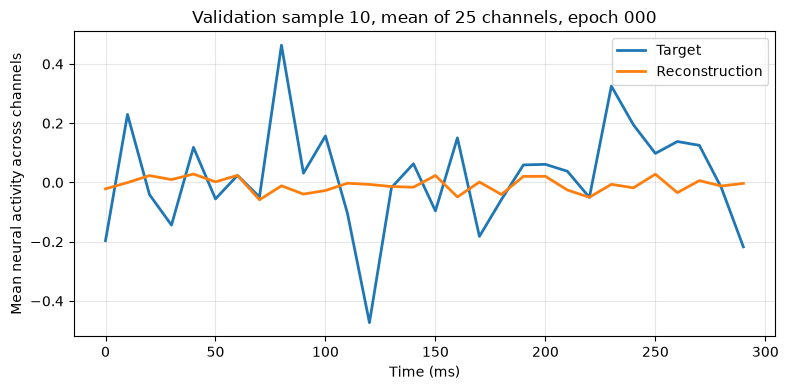

epoch 001/1000 | train reliability-weighted MSE 0.735255 | validation minimum-repetition reliability-weighted MSE 0.507903 | train stim_r 0.0204 | validation stim_r 0.0191
epoch 002/1000 | train reliability-weighted MSE 0.728989 | validation minimum-repetition reliability-weighted MSE 0.503328 | train stim_r 0.0683 | validation stim_r 0.0676
epoch 003/1000 | train reliability-weighted MSE 0.725202 | validation minimum-repetition reliability-weighted MSE 0.501354 | train stim_r 0.1142 | validation stim_r 0.1060
epoch 004/1000 | train reliability-weighted MSE 0.723587 | validation minimum-repetition reliability-weighted MSE 0.502211 | train stim_r 0.1173 | validation stim_r 0.1099
epoch 005/1000 | train reliability-weighted MSE 0.722529 | validation minimum-repetition reliability-weighted MSE 0.502216 | train stim_r 0.1254 | validation stim_r 0.1138
epoch 006/1000 | train reliability-weighted MSE 0.722084 | validation minimum-repetition reliability-weighted MSE 0.502541 | train stim_r 0.

KeyboardInterrupt: 

In [11]:
# Reuse the image-level split created before target preprocessing.
full_dataset = loader.dataset
training_dataset = Subset(full_dataset, training_trial_indices)
validation_dataset = Subset(full_dataset, validation_trial_indices)

# Confirm that repeated presentations never cross the split boundary.
training_image_indices = set(
    full_dataset.image_indices[training_trial_indices].tolist()
)
validation_image_indices = set(validation_trial_image_indices.tolist())
if training_image_indices & validation_image_indices:
    raise RuntimeError("An image appears in both training and validation.")
# end if repeated images leaked across splits
print(
    f"split: {len(training_image_indices)} images / "
    f"{len(training_trial_indices)} trials for training; "
    f"{len(validation_image_indices)} images / "
    f"{len(validation_trial_indices)} trials for validation"
)

# Reliability weighting requires repeated trials. With the switch off,
# an all-ones map makes the shared weighted objective exactly plain MSE.
weight_shape = (raster_array.shape[1], raster_array.shape[0])
self_consistency_reliability = None
neural_response_ceiling = None
if cfg.use_reliability_weighted_loss:
    if cfg.self_consistency_resamples <= 0:
        raise ValueError("self_consistency_resamples must be positive.")
    # end if no split-half resamples were requested

    # Only training identities define the per-cell reliability weights.
    self_consistency_training_mask = np.isin(
        self_consistency_image_indices,
        list(training_image_indices),
    )
    candidate_image_indices, candidate_repetition_counts = np.unique(
        self_consistency_image_indices[self_consistency_training_mask],
        return_counts=True,
    )
    eligible_image_indices = candidate_image_indices[
        candidate_repetition_counts >= 2
    ]
    if len(eligible_image_indices) < 2:
        raise ValueError(
            "Self-consistency requires at least two training images "
            "with at least two repetitions each."
        )
    # end if reliability cannot be estimated

    self_consistency_training_mask &= np.isin(
        self_consistency_image_indices,
        eligible_image_indices,
    )
    selected_self_consistency_image_indices = (
        self_consistency_image_indices[self_consistency_training_mask]
    )
    _, compact_self_consistency_image_ids = np.unique(
        selected_self_consistency_image_indices,
        return_inverse=True,
    )
    selected_self_consistency_targets = self_consistency_trial_targets[
        self_consistency_training_mask
    ]
    stimulus_preference_ceiling = split_half_reliability(
        selected_self_consistency_targets,
        compact_self_consistency_image_ids,
        n_images=len(eligible_image_indices),
        reducer="mean",
        n_resamples=cfg.self_consistency_resamples,
        seed=cfg.random_seed,
    )
    self_consistency_reliability = np.nan_to_num(
        stimulus_preference_ceiling,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    ).astype(np.float32)
    self_consistency_weights = consistency_weights(
        self_consistency_reliability,
        temperature=cfg.temperature,
    ).astype(np.float32)
    weight_description = describe_weights(
        self_consistency_weights,
        self_consistency_reliability,
    )
    print(
        "self-consistency weights [time, neurons] "
        f"{self_consistency_weights.shape} | "
        f"temperature {temperature_label(cfg.temperature)} | "
        f"effective cells "
        f"{weight_description['n_effective_cells']:.1f}/"
        f"{self_consistency_weights.size} | "
        f"max/mean "
        f"{weight_description['weight_max_over_mean']:.3f}"
    )

    # This repeated-response diagnostic is unavailable without raster.
    neural_ceiling_validation_mask = np.isin(
        self_consistency_image_indices,
        list(validation_image_indices),
    )
    neural_ceiling_targets = self_consistency_trial_targets[
        neural_ceiling_validation_mask
    ]
    neural_ceiling_image_indices = self_consistency_image_indices[
        neural_ceiling_validation_mask
    ]
    neural_response_ceiling = crossvalidated_neural_response_mse(
        trial_targets=neural_ceiling_targets,
        image_ids=neural_ceiling_image_indices,
        weights=self_consistency_weights,
        n_resamples=cfg.neural_response_ceiling_resamples,
        evaluation_fraction=(
            cfg.neural_response_ceiling_evaluation_fraction
        ),
        seed=cfg.random_seed,
    )
    print(
        "cross-validated neural-response MSE ceiling | "
        f"minimum {neural_response_ceiling['minimum_mse']:.6f} | "
        f"mean {neural_response_ceiling['mean_mse']:.6f} | "
        f"5--95% "
        f"[{neural_response_ceiling['percentile_05']:.6f}, "
        f"{neural_response_ceiling['percentile_95']:.6f}] | "
        f"{cfg.neural_response_ceiling_resamples} resamples"
    )
else:
    self_consistency_weights = np.ones(weight_shape, dtype=np.float32)
    print(
        "reliability-weighted loss: off | uniform weights "
        f"{self_consistency_weights.shape} | ordinary MSE"
    )
# end if reliability weighting is enabled

pin_memory = torch.device(m.device).type == "cuda"
training_generator = torch.Generator()
training_generator.manual_seed(cfg.random_seed)
training_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=pin_memory,
    generator=training_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)
training_evaluation_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# Repeated trials are averaged by image for correlation and RSA. Natraster
# samples already contain one response per image and therefore need no IDs.
training_correlation_image_ids = None
validation_correlation_image_ids = None
if cfg.neural_data_source == "raster":
    training_correlation_image_ids = np.asarray(
        full_dataset.image_indices[training_trial_indices]
    )
    validation_correlation_image_ids = validation_trial_image_indices
# end if evaluation samples contain repeated image presentations

# Configure regression optimization over trainable parameters only.
optimizer = torch.optim.AdamW(
    m.get_trainable_parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)
self_consistency_weight_tensor = torch.as_tensor(
    self_consistency_weights,
    dtype=torch.float32,
    device=m.device,
)
cost_function = partial(
    neural_activity_weighted_mse_loss,
    weights=self_consistency_weight_tensor,
)
training_metric_label = (
    "reliability-weighted MSE"
    if cfg.use_reliability_weighted_loss
    else "MSE"
)
use_precomputed_features = full_dataset.input_mode == "activations"
if cfg.neural_data_source == "raster":
    # Score each validation image by its best-matching complete trial.
    validation_function = partial(
        minimum_repetition_test_step,
        image_ids=validation_trial_image_indices,
        weights=self_consistency_weights,
    )
    validation_metric_label = (
        "minimum-repetition reliability-weighted MSE"
        if cfg.use_reliability_weighted_loss
        else "minimum-repetition MSE"
    )
else:
    validation_function = partial(test_step, cost_function=cost_function)
    validation_metric_label = training_metric_label
# end if repeated raster validation needs image-wise minima
optimizer.zero_grad(set_to_none=True)

# Fit plain ridge on the same image-grouped split used by the neural model.
ridge_training_features, ridge_training_targets = (
    collect_concatenated_layer_regression_data(
        m,
        training_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_validation_features, ridge_validation_targets = (
    collect_concatenated_layer_regression_data(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_encoding = linear_encoding(
    regression_type="ridge",
    cv_type="same",
)
ridge_encoding.fit(
    ridge_training_features,
    ridge_training_targets,
    transpose=False,
)
ridge_validation_predictions = ridge_encoding.predict(
    ridge_validation_features,
    transpose=False,
    transpose_output=False,
)
target_shape = (raster_array.shape[1], raster_array.shape[0])
ridge_training_targets = ridge_training_targets.reshape(-1, *target_shape)
ridge_validation_targets = ridge_validation_targets.reshape(
    -1, *target_shape
)
ridge_validation_predictions = ridge_validation_predictions.reshape(
    -1, *target_shape
)
# The predict-mean baseline is estimated only from training trials.
training_mean_prediction = ridge_training_targets.mean(axis=0, keepdims=True)
mean_validation_predictions = np.broadcast_to(
    training_mean_prediction,
    ridge_validation_targets.shape,
)
if cfg.neural_data_source == "raster":
    ridge_validation_mse = minimum_repetition_weighted_mse(
        ridge_validation_predictions,
        ridge_validation_targets,
        validation_trial_image_indices,
        self_consistency_weights,
    )
    mean_validation_mse = minimum_repetition_weighted_mse(
        mean_validation_predictions,
        ridge_validation_targets,
        validation_trial_image_indices,
        self_consistency_weights,
    )
else:
    ridge_validation_cell_mse = np.mean(
        (ridge_validation_predictions - ridge_validation_targets) ** 2,
        axis=0,
    )
    mean_validation_cell_mse = np.mean(
        (mean_validation_predictions - ridge_validation_targets) ** 2,
        axis=0,
    )
    ridge_validation_mse = float(np.average(
        ridge_validation_cell_mse, weights=self_consistency_weights
    ))
    mean_validation_mse = float(np.average(
        mean_validation_cell_mse, weights=self_consistency_weights
    ))
# end if validation contains repeated raster trials

# Correlation and RSA compare one population response per validation image.
if cfg.neural_data_source == "raster":
    ridge_image_predictions, ridge_image_ids = average_time_series_by_image(
        ridge_validation_predictions,
        validation_trial_image_indices,
    )
    mean_image_predictions, mean_image_ids = average_time_series_by_image(
        mean_validation_predictions,
        validation_trial_image_indices,
    )
    validation_image_targets, target_image_ids = average_time_series_by_image(
        ridge_validation_targets,
        validation_trial_image_indices,
    )
    if not (
        np.array_equal(ridge_image_ids, target_image_ids)
        and np.array_equal(mean_image_ids, target_image_ids)
    ):
        raise RuntimeError("Regression predictions and targets use different images.")
    # end if image-averaged regression rows are misaligned
else:
    ridge_image_predictions = ridge_validation_predictions
    mean_image_predictions = mean_validation_predictions
    validation_image_targets = ridge_validation_targets
# end if regression arrays contain repeated presentations
ridge_validation_correlation = mean_stimulus_correlation(
    ridge_image_predictions,
    validation_image_targets,
)
mean_validation_correlation = mean_stimulus_correlation(
    mean_image_predictions,
    validation_image_targets,
)

print(
    f"concatenated-layer ridge | {validation_metric_label} "
    f"{ridge_validation_mse:.6f} | mean stim_r "
    f"{ridge_validation_correlation:.4f}"
)
print(
    f"predict training mean | {validation_metric_label} "
    f"{mean_validation_mse:.6f} | mean stim_r undefined "
    "(prediction is constant across images)"
)

# Evaluate the randomly initialized trainable model before any update.
initial_validation_loss = validation_function(
    m,
    validation_loader,
    use_precomputed_features=use_precomputed_features,
    device=m.device,
)
initial_validation_predictions, initial_validation_targets = (
    collect_image_level_predictions(
        m,
        validation_loader,
        use_precomputed_features,
        image_ids=validation_correlation_image_ids,
        device=m.device,
    )
)
initial_validation_correlation = mean_stimulus_correlation(
    initial_validation_predictions,
    initial_validation_targets,
)
best_model_validation_loss = initial_validation_loss
best_model_validation_correlation = initial_validation_correlation
best_model_epoch = 0
best_model_predictions = initial_validation_predictions.copy()
best_model_targets = initial_validation_targets.copy()
print(
    f"epoch 000/{cfg.epochs:03d} | validation "
    f"{validation_metric_label} {initial_validation_loss:.6f} | "
    f"mean stim_r {initial_validation_correlation:.4f}"
)
if cfg.reconstruction_plot_interval <= 0:
    raise ValueError("reconstruction_plot_interval must be positive.")
# end if reconstruction plot interval is invalid
plot_mean_channel_reconstruction(
    m,
    validation_dataset,
    cfg.reconstruction_sample_index,
    epoch=0,
    use_precomputed_features=use_precomputed_features,
    time_start_ms=cfg.time_start_ms,
    sampling_frequency=cfg.new_fs,
    device=m.device,
)

# Run one validation pass after every complete training epoch.
training_losses = []
validation_losses = []
training_correlations = []
validation_correlations = []
for epoch in range(1, cfg.epochs + 1):
    training_loss = training_step(
        m,
        training_loader,
        optimizer,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    validation_loss = validation_function(
        m,
        validation_loader,
        use_precomputed_features=use_precomputed_features,
        device=m.device,
    )
    # Correlations are global across the complete image subset, not averaged
    # over batches. Repeated trials are first averaged within image identity.
    training_image_predictions, training_image_targets = (
        collect_image_level_predictions(
            m,
            training_evaluation_loader,
            use_precomputed_features,
            image_ids=training_correlation_image_ids,
            device=m.device,
        )
    )
    validation_image_predictions, validation_image_targets_from_model = (
        collect_image_level_predictions(
            m,
            validation_loader,
            use_precomputed_features,
            image_ids=validation_correlation_image_ids,
            device=m.device,
        )
    )
    training_correlation = mean_stimulus_correlation(
        training_image_predictions,
        training_image_targets,
    )
    validation_correlation = mean_stimulus_correlation(
        validation_image_predictions,
        validation_image_targets_from_model,
    )
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    training_correlations.append(training_correlation)
    validation_correlations.append(validation_correlation)

    # Retain the prediction array from the epoch selected by validation MSE.
    if validation_loss < best_model_validation_loss:
        best_model_validation_loss = validation_loss
        best_model_validation_correlation = validation_correlation
        best_model_epoch = epoch
        best_model_predictions = validation_image_predictions.copy()
        best_model_targets = validation_image_targets_from_model.copy()
    # end if this epoch is the best validation model so far

    print(
        f"epoch {epoch:03d}/{cfg.epochs:03d} | "
        f"train {training_metric_label} {training_loss:.6f} | "
        f"validation {validation_metric_label} {validation_loss:.6f} | "
        f"train stim_r {training_correlation:.4f} | "
        f"validation stim_r {validation_correlation:.4f}"
    )

    # Show progress periodically and always include the final model.
    should_plot_reconstruction = (
        epoch % cfg.reconstruction_plot_interval == 0
        or epoch == cfg.epochs
    )
    if should_plot_reconstruction:
        plot_mean_channel_reconstruction(
            m,
            validation_dataset,
            cfg.reconstruction_sample_index,
            epoch=epoch,
            use_precomputed_features=use_precomputed_features,
            time_start_ms=cfg.time_start_ms,
            sampling_frequency=cfg.new_fs,
            device=m.device,
        )
    # end if reconstruction should be plotted
# end for epoch
print(
    f"best model predictions retained from epoch {best_model_epoch:03d} | "
    f"validation {validation_metric_label} {best_model_validation_loss:.6f} | "
    f"mean stim_r {best_model_validation_correlation:.4f}"
)
if mean_validation_mse > 0:
    best_mse_reduction = 1.0 - (
        best_model_validation_loss / mean_validation_mse
    )
    ridge_mse_reduction = 1.0 - (
        ridge_validation_mse / mean_validation_mse
    )
    print(
        "MSE reduction relative to predicting the training mean | "
        f"best neural model {best_mse_reduction:.1%} | "
        f"ridge {ridge_mse_reduction:.1%}"
    )
# end if the predict-mean reference has nonzero MSE


torch.Size([256, 30, 25])


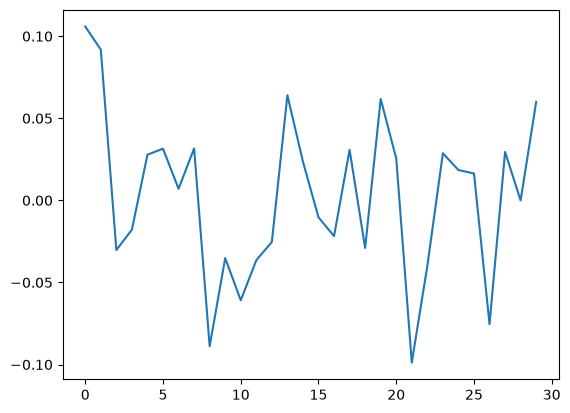

In [12]:
for i in training_loader:
    print(i[1].shape)
    y = i[1][:, :, 1].mean(dim=0)
    plt.plot(y.detach().cpu().numpy())
    break

## MSE, correlation, ridge references, and temporal source attention

The first panel retains the scale-sensitive MSE curves and references. The second reports mean Pearson stimulus correlation across validation images, which reveals whether a numerically small or large MSE nevertheless preserves image selectivity. The predict-mean baseline has undefined correlation because it is constant across images. The remaining panels show source attention and the Gaussian-noise control.


mean noise attention by time bin: [0.2355 0.2355 0.2355 0.2265 0.2265 0.2265 0.2294 0.2294 0.2294 0.2151
 0.2151 0.2151 0.2274 0.2274 0.2274 0.2344 0.2344 0.2344 0.2377 0.2377
 0.2377 0.2356 0.2356 0.2356 0.2382 0.2382 0.2382 0.2407 0.2407 0.2407]
overall mean noise attention: 0.2321
feature attention | best validation 0.499544 at epoch 037


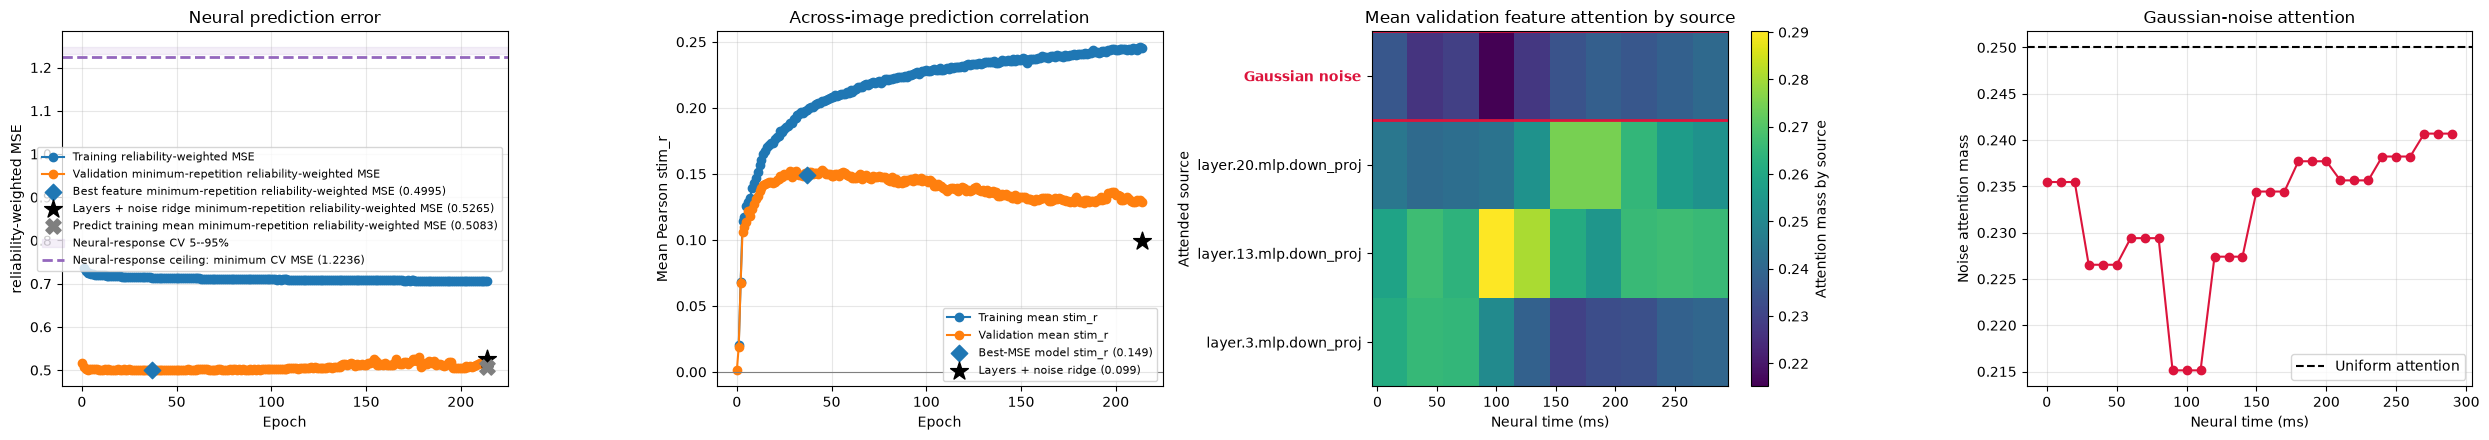

In [13]:
# Average attention over validation stimuli and independent noise draws.
m.eval()
if cfg.attention_evaluation_repeats <= 0:
    raise ValueError("attention_evaluation_repeats must be positive.")
# end if no attention-evaluation repeats were requested
torch.manual_seed(cfg.random_seed + 1)
validation_attention = []
with torch.no_grad():
    for _ in range(cfg.attention_evaluation_repeats):
        for inputs, _ in validation_loader:
            inputs = inputs.to(m.device)
            _, attention_weights = m(
                inputs,
                use_precomputed_features=use_precomputed_features,
            )
            source_attention = aggregate_attention_by_layer(
                attention_weights
            )
            validation_attention.append(source_attention.cpu())
        # end for validation batch
    # end for independent noise draw
# end with no gradient tracking

mean_source_attention = torch.cat(validation_attention, dim=0).mean(dim=0)

# Attention is constant inside each fine-time block produced by one coarse query.
mean_fine_attention = mean_source_attention.repeat_interleave(
    m.get_temporal_compression_ratio(),
    dim=0,
)
source_labels = [*cfg.layer_names, "Gaussian noise"]
if len(source_labels) != mean_fine_attention.shape[1]:
    raise RuntimeError("Attention sources do not match heatmap labels.")
# end if the source axis is inconsistent
noise_attention = mean_fine_attention[:, -1].numpy()
time_ms = cfg.time_start_ms + (
    np.arange(noise_attention.size) * 1000.0 / cfg.new_fs
)
print(
    "mean noise attention by time bin: "
    + np.array2string(noise_attention, precision=4)
)
print(f"overall mean noise attention: {noise_attention.mean():.4f}")

# Plot optimization error and the final validation-set attention schedule.
training_epochs = np.arange(1, len(training_losses) + 1)
validation_epochs = np.arange(0, len(validation_losses) + 1)
all_validation_losses = np.asarray(
    [initial_validation_loss, *validation_losses]
)
best_validation_index = int(np.argmin(all_validation_losses))
best_validation_epoch = int(validation_epochs[best_validation_index])
best_validation_loss = float(
    all_validation_losses[best_validation_index]
)
print(
    f"{cfg.attention_granularity} attention | best validation "
    f"{best_validation_loss:.6f} at epoch {best_validation_epoch:03d}"
)

fig, axes = plt.subplots(1, 4, figsize=(25, 4.5))
axes[0].plot(
    training_epochs,
    training_losses,
    marker="o",
    label=f"Training {training_metric_label}",
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker="o",
    label=f"Validation {validation_metric_label}",
)
axes[0].scatter(
    best_validation_epoch,
    best_validation_loss,
    marker="D",
    s=70,
    zorder=4,
    label=(
        f"Best {cfg.attention_granularity} "
        f"{validation_metric_label} "
        f"({best_validation_loss:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_validation_mse,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=(
        f"Layers + noise ridge {validation_metric_label} "
        f"({ridge_validation_mse:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    mean_validation_mse,
    marker="X",
    s=120,
    color="tab:gray",
    zorder=4,
    label=(
        f"Predict training mean {validation_metric_label} "
        f"({mean_validation_mse:.4f})"
    ),
)
if neural_response_ceiling is not None:
    axes[0].axhspan(
        neural_response_ceiling['percentile_05'],
        neural_response_ceiling['percentile_95'],
        color="tab:purple",
        alpha=0.10,
        label="Neural-response CV 5--95%",
    )
    axes[0].axhline(
        neural_response_ceiling['minimum_mse'],
        color="tab:purple",
        linestyle="--",
        linewidth=2,
        label=(
            "Neural-response ceiling: minimum CV MSE "
            f"({neural_response_ceiling['minimum_mse']:.4f})"
        ),
    )
# end if repeated-raster ceiling diagnostics are available
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel(training_metric_label)
axes[0].set_title("Neural prediction error")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# Correlation is computed across validation images for every time/neuron cell,
# then averaged over the finite cells. It is insensitive to output scale.
all_validation_correlations = np.asarray(
    [initial_validation_correlation, *validation_correlations]
)
axes[1].plot(
    training_epochs,
    training_correlations,
    marker="o",
    label="Training mean stim_r",
)
axes[1].plot(
    validation_epochs,
    all_validation_correlations,
    marker="o",
    label="Validation mean stim_r",
)
axes[1].scatter(
    best_model_epoch,
    best_model_validation_correlation,
    marker="D",
    s=70,
    zorder=4,
    label=(
        f"Best-MSE model stim_r "
        f"({best_model_validation_correlation:.3f})"
    ),
)
axes[1].scatter(
    validation_epochs[-1],
    ridge_validation_correlation,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=f"Layers + noise ridge ({ridge_validation_correlation:.3f})",
)
axes[1].axhline(0.0, color="grey", linewidth=0.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Pearson stim_r")
axes[1].set_title("Across-image prediction correlation")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

attention_image = axes[2].imshow(
    mean_fine_attention.T.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
heatmap_tick_indices = np.arange(0, len(time_ms), 5)
axes[2].set_xticks(heatmap_tick_indices)
axes[2].set_xticklabels(time_ms[heatmap_tick_indices].astype(int))
axes[2].set_xlabel("Neural time (ms)")
axes[2].set_ylabel("Attended source")
axes[2].set_title(
    f"Mean validation {cfg.attention_granularity} attention by source"
)
axes[2].set_yticks(np.arange(len(source_labels)))
axes[2].set_yticklabels(source_labels)
noise_tick = axes[2].get_yticklabels()[-1]
noise_tick.set_color("crimson")
noise_tick.set_fontweight("bold")

# Mark the noise row and repeat it as a line plot for precise inspection.
noise_source_index = len(source_labels) - 1
axes[2].axhline(noise_source_index - 0.5, color="crimson", linewidth=2)
axes[2].axhline(noise_source_index + 0.5, color="crimson", linewidth=2)
fig.colorbar(
    attention_image,
    ax=axes[2],
    label="Attention mass by source",
)
axes[3].plot(time_ms, noise_attention, color="crimson", marker="o")
axes[3].axhline(
    1.0 / len(source_labels),
    color="black",
    linestyle="--",
    label="Uniform attention",
)
axes[3].set_xlabel("Neural time (ms)")
axes[3].set_ylabel("Noise attention mass")
axes[3].set_title("Gaussian-noise attention")
axes[3].grid(alpha=0.3)
axes[3].legend()
fig.tight_layout()
plt.show()


## Dynamic RSA of ridge and best-model predictions

For each validation time bin, an RDM is computed across images from the observed neural population. Separate RDM time series are computed from the ridge predictions and from the predictions retained at the lowest validation MSE epoch. Each matrix entry compares one observed-neural RDM (row) with one predicted-response RDM (column). The diagonal is therefore the matched-time RSA time course; off-diagonal structure shows temporal shifts in the predicted representational geometry.


Best neural model         | peak aligned dRSA 0.382 at 160 ms | mean 0.143
Concatenated-layer ridge  | peak aligned dRSA 0.360 at 160 ms | mean 0.122


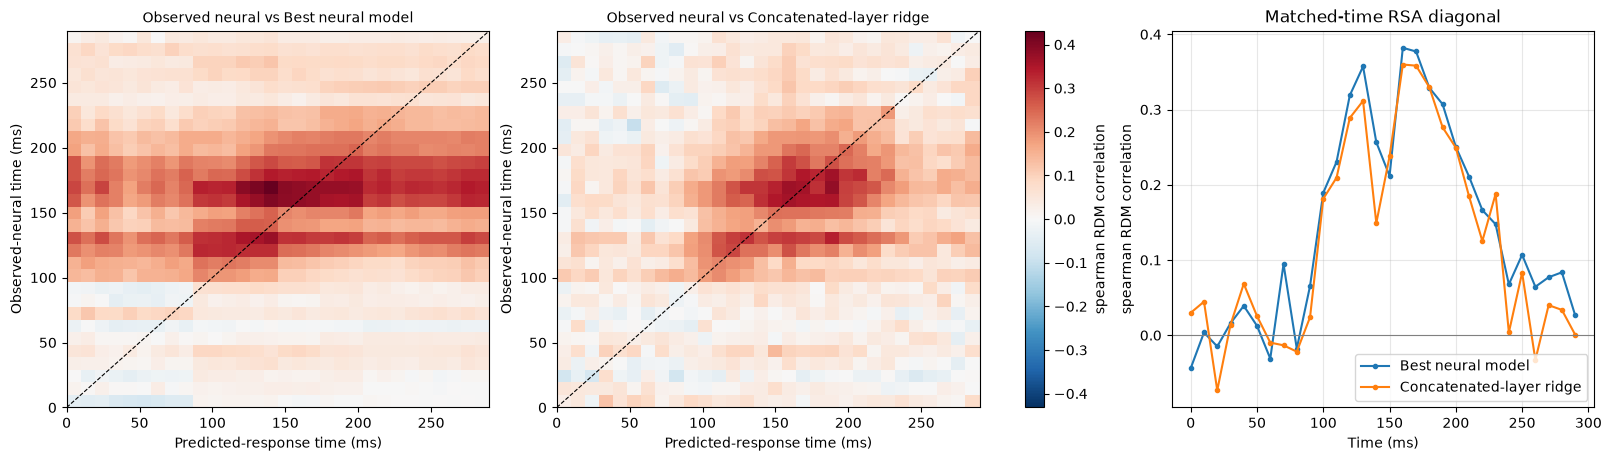

: 

In [ ]:
# Build one validation-image RDM at every neural and prediction time bin.
if best_model_targets.shape != validation_image_targets.shape:
    raise RuntimeError(
        "Best-model and ridge targets have different image-level shapes."
    )
# end if the two prediction families use different validation targets
if not np.allclose(best_model_targets, validation_image_targets):
    raise RuntimeError(
        "Best-model and ridge targets are not aligned in validation-image order."
    )
# end if target rows are not identical

prepared_neural_rdms = prepared_rdm_time_series(
    validation_image_targets,
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)
prepared_best_model_rdms = prepared_rdm_time_series(
    best_model_predictions,
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)
prepared_ridge_rdms = prepared_rdm_time_series(
    ridge_image_predictions,
    rdm_metric=cfg.drsa_rdm_metric,
    rsa_metric=cfg.drsa_rsa_metric,
)

prediction_drsa = {
    "Best neural model": drsa_from_prepared(
        prepared_neural_rdms,
        prepared_best_model_rdms,
    ),
    "Concatenated-layer ridge": drsa_from_prepared(
        prepared_neural_rdms,
        prepared_ridge_rdms,
    ),
}
drsa_times_ms = time_axis_ms(
    validation_image_targets.shape[1],
    cfg.new_fs,
    cfg.time_start_ms,
)
drsa_limit = float(
    np.nanmax([
        np.abs(drsa_matrix)
        for drsa_matrix in prediction_drsa.values()
    ])
)

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4.5), layout="constrained"
)
for axis, (model_label, drsa_matrix) in zip(
    axes[:2], prediction_drsa.items()
):
    drsa_image = plot_drsa_matrix(
        axis,
        drsa_matrix,
        drsa_times_ms,
        drsa_times_ms,
        f"Observed neural vs {model_label}",
        row_label="Observed-neural time (ms)",
        column_label="Predicted-response time (ms)",
        vmin=-drsa_limit,
        vmax=drsa_limit,
    )
# end for predicted-response dRSA matrix
fig.colorbar(
    drsa_image,
    ax=axes[:2],
    label=f"{cfg.drsa_rsa_metric} RDM correlation",
)

# The identity diagonal compares observed and predicted geometry at equal times.
for model_label, drsa_matrix in prediction_drsa.items():
    aligned_drsa = np.diagonal(drsa_matrix)
    peak_index = int(np.nanargmax(aligned_drsa))
    axes[2].plot(
        drsa_times_ms,
        aligned_drsa,
        marker="o",
        markersize=3,
        label=model_label,
    )
    print(
        f"{model_label:25s} | peak aligned dRSA "
        f"{aligned_drsa[peak_index]:.3f} at "
        f"{drsa_times_ms[peak_index]:.0f} ms | "
        f"mean {np.nanmean(aligned_drsa):.3f}"
    )
# end for aligned dRSA time course
axes[2].axhline(0.0, color="grey", linewidth=0.8)
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel(f"{cfg.drsa_rsa_metric} RDM correlation")
axes[2].set_title("Matched-time RSA diagonal")
axes[2].grid(alpha=0.3)
axes[2].legend()
plt.show()
